In [201]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt

# Problem 1. 

(a) Make graphs of the largest infected component of $G'$ as a function of the parameter $\phi$ (component size on the y-axis, $\phi$ on the x-axis) for some value of $p$ (and $n=10000$) and some reasonable range of $\phi$. If your computations take more than a few minutes, you may want to adjust parameters to decrease the number of $\phi$ values computed or the number of edges in $G$.

(b) What trends do you see in the graph? Can you achieve fundamentally different trends with a different choice of $p$? Explain why or why not.

- The largest connected component stays small for $0<\phi<0.2$. Then from $0.2<\phi<1$, the size of the largest component grows rapidly, asymptoting at a largest component of  10,000.
- You cannot achieve fundamentally different trends with a different choice of $p$. Increasing $p$ causes the graph to follow the same pattern, however it saturates sooner. For example the size of the largest connected component saturates by $\phi=0.2$ when $p=0.004$.  If $p$ is too small, the graph will become sparse and the largest connected component will be very small, so it won't saturate. But regardless, the largest connected component will increase as $\phi$ increases.

(c) In your numerical simulations, when would you say an epidemic occurs? If an epidemic does not occur, explain why (in terms of the simulation, not in real life).

- In these numerical simulations, an epidemic occurs for $0.2<\phi<1$. An epidemic does not occur for $0<\phi<0.2$ because the graph is too sparse for the infection to spread efficiently.

(e) Optional: Discuss how likely it is that the largest connected component of $G'$ does NOT become infected.

- The probability that the largest connected component of $G'$ does NOT become infected is $1-\phi$.

Text(0, 0.5, 'Largest Component')

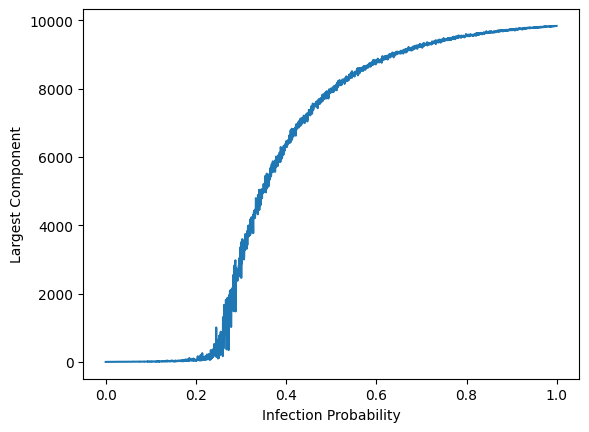

In [245]:
n = 10000; p = 0.0004; phi = 0.1; 
G = nx.erdos_renyi_graph(n,p)

# Compute largest components for example graphs at an array of probabilities of infection.
Phi = np.arange(0,1,0.0005)
comps = []
for phi in Phi:
    Gprime = simulate_outbreak(G,phi) # keep
    largest_comp = return_largest_comp(Gprime,infected_nodes)
    comps.append(largest_comp) # keep


plt.plot(Phi,comps)
plt.xlabel("Infection Probability")
plt.ylabel("Largest Component")

Text(0, 0.5, 'Largest Component')

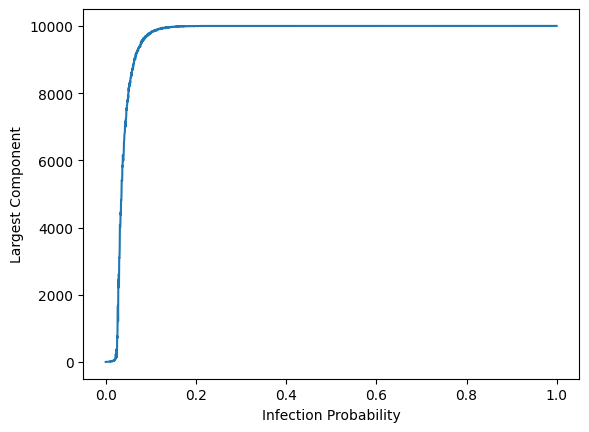

In [244]:
n = 10000; p = 0.004; phi = 0.1; 
G = nx.erdos_renyi_graph(n,p)

# Compute largest components for example graphs at an array of probabilities of infection.
Phi = np.arange(0,1,0.0005)
comps = []
for phi in Phi:
    Gprime = simulate_outbreak(G,phi) # keep
    largest_comp = return_largest_comp(Gprime,infected_nodes)
    comps.append(largest_comp) # keep


plt.plot(Phi,comps)
plt.xlabel("Infection Probability")
plt.ylabel("Largest Component")

### Let's explore adding vaccination to the model.

Assumptions:

(a) Vaccinated individuals have perfect immunity throughout the course of the disease spread.

(b) All vaccinated individuals are vaccinated at the start of the disease spread and no one else is vaccinated during disease spread.


Algorithm:

We could add node labels to our graph indicating who is in the recovered compartment, and then delete all edges impinging on those nodes. But given the fact that we are only trying to find the infected components of the graph, we can instead just delete the nodes representing the recovered class.  

In [230]:
n = 10000; p = 0.0004; phi = 0.1; 
G = nx.erdos_renyi_graph(n,p)

conn_comp_prime = sorted(nx.connected_components(G), key=len, reverse=True)
size_of_conn_comp_prime = [len(c) for c in conn_comp_prime]
print("The largest connected component of G has {} nodes.".format(size_of_conn_comp_prime[0]))



The largest connected component of G has 9818 nodes.


In [231]:
V0 = 0.1; # proportion of vaccinated individuals 
vaccinated_nodes = random.sample(range(n),int(n*V0))
Gv = G.copy()
Gv.remove_nodes_from(vaccinated_nodes)

conn_comp_prime = sorted(nx.connected_components(Gv), key=len, reverse=True)
size_of_conn_comp_prime = [len(c) for c in conn_comp_prime]
print("The largest connected component of Gv has {} nodes.".format(size_of_conn_comp_prime[0]))

Gprime = simulate_outbreak(Gv,phi)


The largest connected component of Gv has 8735 nodes.


In [232]:
I0 = 100; 
infected_nodes = random.sample(range(n),I0)
infected_comps = find_components(Gprime,infected_nodes)
print([(i,infected_comps.count(i)) for i in sorted(set(infected_comps),reverse=True)])

The largest connected component of Gprime has 11 nodes.
[(5, 2), (4, 2), (3, 13), (2, 15), (1, 65)]


# Problem 2. 

(a) Graph the largest infected component size as a function of the proportion of vaccinated individuals for some fixed values of $p$ and $\phi$ (with $n=10000$). What trends do you see? What is the critical proportion of vaccinated individuals that stops an epidemic at those parameters?

- For $V_0\in(0,0.2)$, the size of the largest connected component has a steep decrease with a slope of -17,500 largest connected components per proportion of vaccinated individuals. After this, the line flattens out and the noise decreases as more of the population becomes vaccinated. Looking at the graph, vaccinating 20% of the population is the critical number that stops an epidemic with the parameters $p=0.0004$ and $\phi=0.3$. Vaccinating at least 40% of the population seems the most ideal, as most of the noise fades at this point.

(b) Repeat for another choice of $p$ and/or $\phi$ that gives you a significantly different trend.

- Vaccination is not needed to prevent an epidemic at the parameters $p=0.0004$ and $\phi=0.1$. Interesting behavior for this graph is how it almost seems like a decreasing step function.

(c) Repeat for another choice of $p$ and/or $\phi$ that gives you a significantly different trend.

- For $V_0\in(0,0.6)$, the size of the largest connected component has a steep decrease with a slope of -42,500 largest connected components per proportion of vaccinated individuals. After this, the line flattens out and the noise decreases as more of the population becomes vaccinated. Looking at the graph, vaccinating 60% of the population is the critical number that stops an epidemic with the parameters $p=0.0009$ and $\phi=0.3$.

Text(0, 0.5, 'Largest Component')

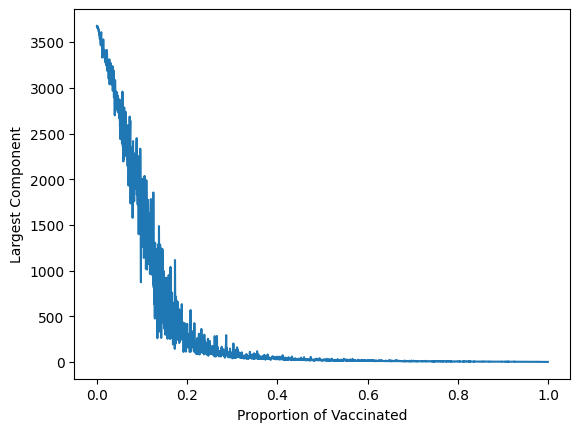

In [233]:
# (a)
n = 10000; p = 0.0004; phi = 0.3; 
G = nx.erdos_renyi_graph(n,p)
Gprime=simulate_outbreak(G,phi)
# Compute largest components for example graphs at an array of proportion of vaccinated individuals with 100% efficacy.
V0 = np.arange(0,1,0.0005)
comps = []
for v in V0:
    vaccinated_nodes = random.sample(range(n),int(n*v))
    Gv = Gprime.copy()
    Gv.remove_nodes_from(vaccinated_nodes)

    conn_comp_prime = sorted(nx.connected_components(Gv), key=len, reverse=True)
    size_of_conn_comp_prime = [len(c) for c in conn_comp_prime]
    comps.append(size_of_conn_comp_prime[0])

plt.plot(V0,comps)
plt.xlabel("Proportion of Vaccinated")
plt.ylabel("Largest Component")

Text(0, 0.5, 'Largest Component')

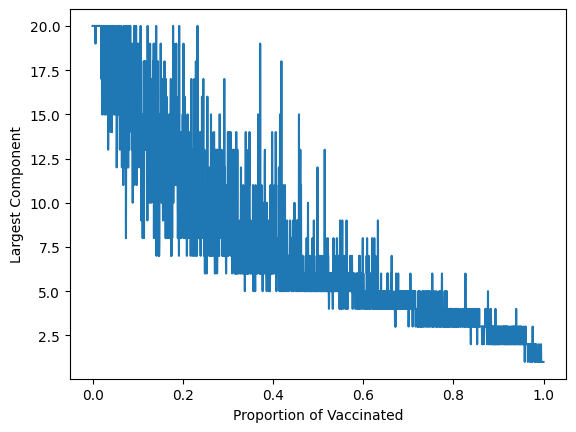

In [234]:
# (b)
n = 10000; p = 0.0004; phi = 0.1; 
G = nx.erdos_renyi_graph(n,p)
Gprime=simulate_outbreak(G,phi)
# Compute largest components for example graphs at an array of proportion of vaccinated individuals with 100% efficacy.
V0 = np.arange(0,1,0.0005)
comps = []
for v in V0:
    vaccinated_nodes = random.sample(range(n),int(n*v))
    Gv = Gprime.copy()
    Gv.remove_nodes_from(vaccinated_nodes)

    conn_comp_prime = sorted(nx.connected_components(Gv), key=len, reverse=True)
    size_of_conn_comp_prime = [len(c) for c in conn_comp_prime]
    comps.append(size_of_conn_comp_prime[0])

plt.plot(V0,comps)
plt.xlabel("Proportion of Vaccinated")
plt.ylabel("Largest Component")

Text(0, 0.5, 'Largest Component')

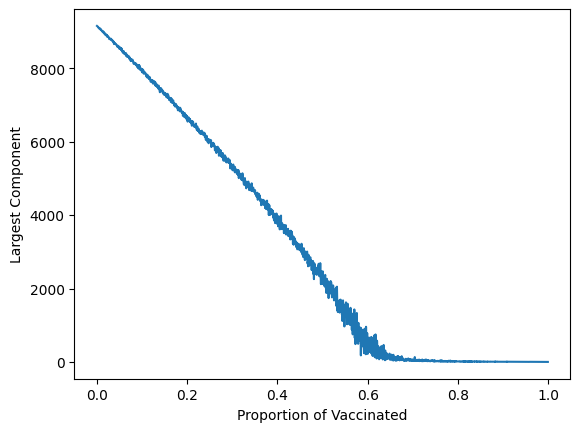

In [235]:
# (c)
n = 10000; p = 0.0009; phi = 0.3; 
G = nx.erdos_renyi_graph(n,p)
Gprime=simulate_outbreak(G,phi)
# Compute largest components for example graphs at an array of proportion of vaccinated individuals with 100% efficacy.
V0 = np.arange(0,1,0.0005)
comps = []
for v in V0:
    vaccinated_nodes = random.sample(range(n),int(n*v))
    Gv = Gprime.copy()
    Gv.remove_nodes_from(vaccinated_nodes)

    conn_comp_prime = sorted(nx.connected_components(Gv), key=len, reverse=True)
    size_of_conn_comp_prime = [len(c) for c in conn_comp_prime]
    comps.append(size_of_conn_comp_prime[0])

plt.plot(V0,comps)
plt.xlabel("Proportion of Vaccinated")
plt.ylabel("Largest Component")

# Problem 3 (Optional). 

Alter the model so that vaccination efficacy $q$ is less than 100\%. Graphically explore epidemic size as a function of $q$, and explain your figures.

- Decreasing the efficacy of the vaccine increases the point at which enough individuals have been vaccinated to prevent an epidemic. At 75%, at least 30% of the population needs to be vaccinated. At 50%, at least 50% of the population needs to be vaccinated. and at 25% efficacy, at least 80% of the population needs to be vaccinated, but the largest connected component may still range from 0 to 500.

AND/OR

Repeat Problem 1 with the configuration model. `networkx` has a `configuration_model` command. Remember that you will have to generate degree sequences.

- The size of the larges connected component does not saturate when using the configuration model. This could be because the removed multiple edges and self-loops took up the space of possible connections, impacting the behavior of our graph.

Text(0, 0.5, 'Largest Component')

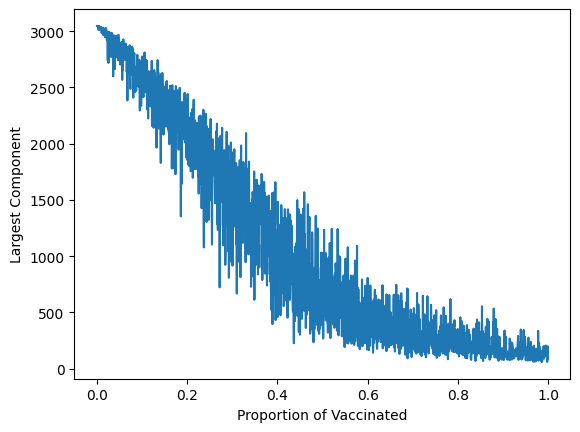

In [236]:
n = 10000; p = 0.0004; phi = 0.3; q=0.25
G = nx.erdos_renyi_graph(n,p)
Gprime=simulate_outbreak(G,phi)
# Compute largest components for example graphs at an array of proportion of vaccinated individuals with 25% efficacy.
V0 = np.arange(0,1,0.0005)
comps = []
for v in V0:
    vaccinated_nodes = random.sample(range(n),int(q*n*v))
    Gv = Gprime.copy()
    Gv.remove_nodes_from(vaccinated_nodes)

    conn_comp_prime = sorted(nx.connected_components(Gv), key=len, reverse=True)
    size_of_conn_comp_prime = [len(c) for c in conn_comp_prime]
    comps.append(size_of_conn_comp_prime[0])

plt.plot(V0,comps)
plt.xlabel("Proportion of Vaccinated")
plt.ylabel("Largest Component")

Text(0, 0.5, 'Largest Component')

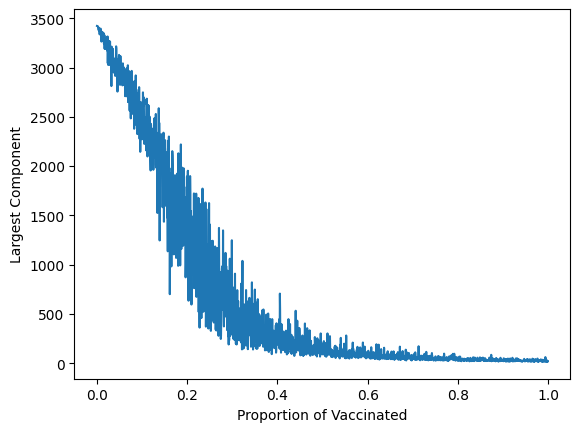

In [237]:
n = 10000; p = 0.0004; phi = 0.3; q=0.5
G = nx.erdos_renyi_graph(n,p)
Gprime=simulate_outbreak(G,phi)
# Compute largest components for example graphs at an array of proportion of vaccinated individuals with 50% efficacy.
V0 = np.arange(0,1,0.0005)
comps = []
for v in V0:
    vaccinated_nodes = random.sample(range(n),int(q*n*v))
    Gv = Gprime.copy()
    Gv.remove_nodes_from(vaccinated_nodes)

    conn_comp_prime = sorted(nx.connected_components(Gv), key=len, reverse=True)
    size_of_conn_comp_prime = [len(c) for c in conn_comp_prime]
    comps.append(size_of_conn_comp_prime[0])

plt.plot(V0,comps)
plt.xlabel("Proportion of Vaccinated")
plt.ylabel("Largest Component")

Text(0, 0.5, 'Largest Component')

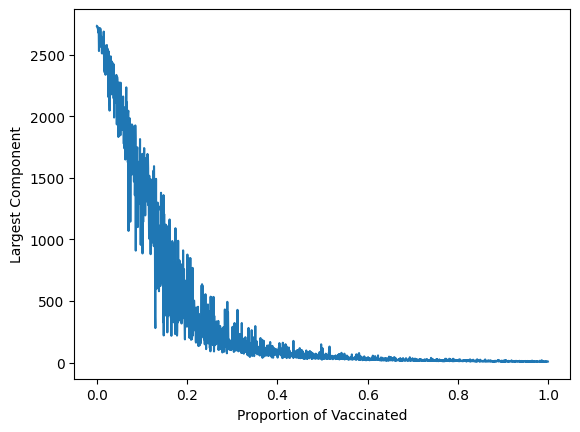

In [238]:
n = 10000; p = 0.0004; phi = 0.3; q=0.75
G = nx.erdos_renyi_graph(n,p)
Gprime=simulate_outbreak(G,phi)
# Compute largest components for example graphs at an array of proportion of vaccinated individuals with 75% efficacy.
V0 = np.arange(0,1,0.0005)
comps = []
for v in V0:
    vaccinated_nodes = random.sample(range(n),int(q*n*v))
    Gv = Gprime.copy()
    Gv.remove_nodes_from(vaccinated_nodes)

    conn_comp_prime = sorted(nx.connected_components(Gv), key=len, reverse=True)
    size_of_conn_comp_prime = [len(c) for c in conn_comp_prime]
    comps.append(size_of_conn_comp_prime[0])

plt.plot(V0,comps)
plt.xlabel("Proportion of Vaccinated")
plt.ylabel("Largest Component")

Text(0, 0.5, 'Largest Component')

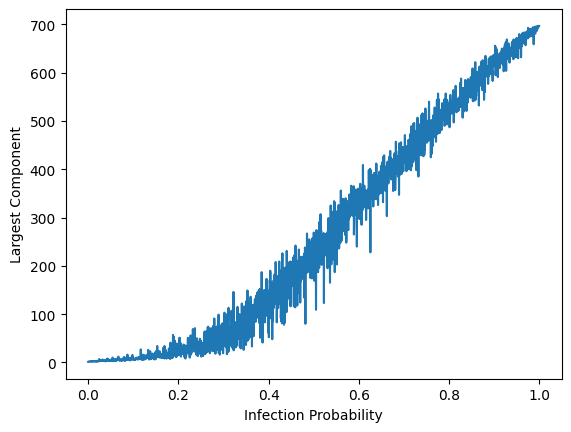

In [239]:
sequence = nx.random_powerlaw_tree_sequence(1000, tries=100000)
G=nx.configuration_model(sequence)
G=nx.Graph(G)
# Compute largest components for example graphs at an array of probabilities of infection using configuration_model.
Phi = np.arange(0,1,0.0005)
comps = []
for phi in Phi:
    Gprime = simulate_outbreak(G,phi) # keep
    largest_comp = return_largest_comp(Gprime,infected_nodes)
    comps.append(largest_comp) # keep


plt.plot(Phi,comps)
plt.xlabel("Infection Probability")
plt.ylabel("Largest Component")